In [4]:
VLM_BATCH = 128
ATTACK_SPLITS = ['Training', 'Validation']

In [5]:
!pip install ultralytics -q

import csv, os, shutil, zipfile, time
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from collections import defaultdict
import re as re_mod

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [6]:
from google.colab import drive
drive.mount('/content/drive')

BASE_SAVE_DIR = '/content/drive/MyDrive/recaptcha dataset with rare samples'
SAVE_ROOT = os.path.join(BASE_SAVE_DIR, 'all_samples_untargeted_pgd_eps4_v2')
ADV_DIR = os.path.join(SAVE_ROOT, 'adversarial_images')
RESULTS_CSV = os.path.join(SAVE_ROOT, 'results.csv')

DATASET_ROOT = '/content/recaptcha-dataset-master'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'Training')
VAL_DIR = os.path.join(DATASET_ROOT, 'Validation')
SPLIT_TO_DIR = {'Training': TRAIN_DIR, 'Validation': VAL_DIR}

# Extract dataset
if not os.path.isdir(DATASET_ROOT):
    with zipfile.ZipFile(os.path.join(BASE_SAVE_DIR, 'recaptcha-dataset-master.zip'), 'r') as z:
        z.extractall('/content')
    print('Extracted.')
else:
    print('Dataset ready.')


assert os.path.exists(RESULTS_CSV), f'Step 1 v2 results not found: {RESULTS_CSV}'
assert os.path.isdir(ADV_DIR), f'Step 1 v2 adversarial images not found: {ADV_DIR}'
n_csv = sum(1 for _ in csv.DictReader(open(RESULTS_CSV)))
print(f'Step 1 v2 results: {n_csv} rows')

# Load class names from YOLO (13 classes)
from ultralytics import YOLO
MODEL_DST = '/content/classification_model.pt'
if not os.path.exists(MODEL_DST):
    shutil.copy(os.path.join(BASE_SAVE_DIR, 'classification_model.pt'), MODEL_DST)
yolo = YOLO(MODEL_DST)
N_CLASSES = 13
CLASS_NAMES = yolo.names
NAME_TO_IDX = {v: k for k, v in CLASS_NAMES.items()}
del yolo

expected = ['Bicycle','Bridge','Bus','Car','Chimney','Crosswalk','Hydrant',
            'Motorcycle','Mountain','Other','Palm','Stairs','Traffic Light']
assert [CLASS_NAMES[i] for i in range(13)] == expected, \
    f'Class order mismatch! Got: {[CLASS_NAMES[i] for i in range(13)]}'
print('Class-index alignment verified')

import PIL.Image
_original_open = PIL.Image.open.__wrapped__ if hasattr(PIL.Image.open, '__wrapped__') else PIL.Image.open
print('Ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted.
Step 1 v2 results: 11849 rows
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Class-index alignment verified
Ready.


In [ ]:
# ── Load VLM (Holo1-7B) ─────────────────────────────────────────────────────────────
import gc
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

from transformers import AutoModelForImageTextToText, AutoProcessor
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize

print('Loading Holo1-7B...')
vlm_model = AutoModelForImageTextToText.from_pretrained(
    'Hcompany/Holo1-7B', torch_dtype='auto', device_map='auto'
)
vlm_processor = AutoProcessor.from_pretrained('Hcompany/Holo1-7B', use_fast=True)

vlm_processor.tokenizer.padding_side = 'left'
print(f'Padding side: {vlm_processor.tokenizer.padding_side}')
print('VLM loaded!')

# ── Shared helpers ─────────────────────────────────────────────────────────────
def resize_for_vlm(pil_image):
    ip = vlm_processor.image_processor
    min_px = getattr(ip, 'min_pixels', None) or 3136
    max_px = getattr(ip, 'max_pixels', None) or 3145728
    factor = ip.patch_size * getattr(ip, 'merge_size', 1)
    h, w = smart_resize(pil_image.height, pil_image.width,
                        factor=factor, min_pixels=min_px, max_pixels=max_px)
    return pil_image.resize((w, h), Image.LANCZOS)

def vlm_batch_inference(image_pils, prompt_text):
    """Run batched VLM inference. Returns list of raw output strings."""
    batch_texts = []
    for _ in image_pils:
        msgs = [{'role': 'user', 'content': [
            {'type': 'image'}, {'type': 'text', 'text': prompt_text}
        ]}]
        batch_texts.append(vlm_processor.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True))
    inputs = vlm_processor(text=batch_texts, images=image_pils,
                           padding=True, return_tensors='pt').to('cuda')
    with torch.no_grad():
        gen_ids = vlm_model.generate(**inputs, max_new_tokens=16)
    results = []
    for j in range(len(image_pils)):
        trimmed = gen_ids[j][len(inputs.input_ids[j]):]
        results.append(vlm_processor.decode(trimmed, skip_special_tokens=True).strip())
    return results

SANITY CHECK: VLM clean accuracy (16-class numeric prompt)
         Bicycle |   74 imgs | acc=95% | Validation
          Bridge |   74 imgs | acc=84% | Validation
             Bus |   74 imgs | acc=99% | Validation
             Car |   74 imgs | acc=85% | Validation
         Chimney |   17 imgs | acc=88% | Validation
       Crosswalk |   74 imgs | acc=42% | Validation
         Hydrant |   74 imgs | acc=100% | Validation
      Motorcycle |   74 imgs | acc=93% | Validation
        Mountain |    2 imgs | acc=50% | Validation
           Other |   74 imgs | acc=22% | Validation
            Palm |   74 imgs | acc=70% | Validation
   Traffic Light |   74 imgs | acc=93% | Validation
            Boat |   11 imgs | acc=100% | Training (held-out)
          Stairs |   75 imgs | acc=95% | Training (held-out)
            Taxi |   28 imgs | acc=82% | Training (held-out)
         Tractor |   20 imgs | acc=100% | Training (held-out)

Overall: 720/893 (80.6%)


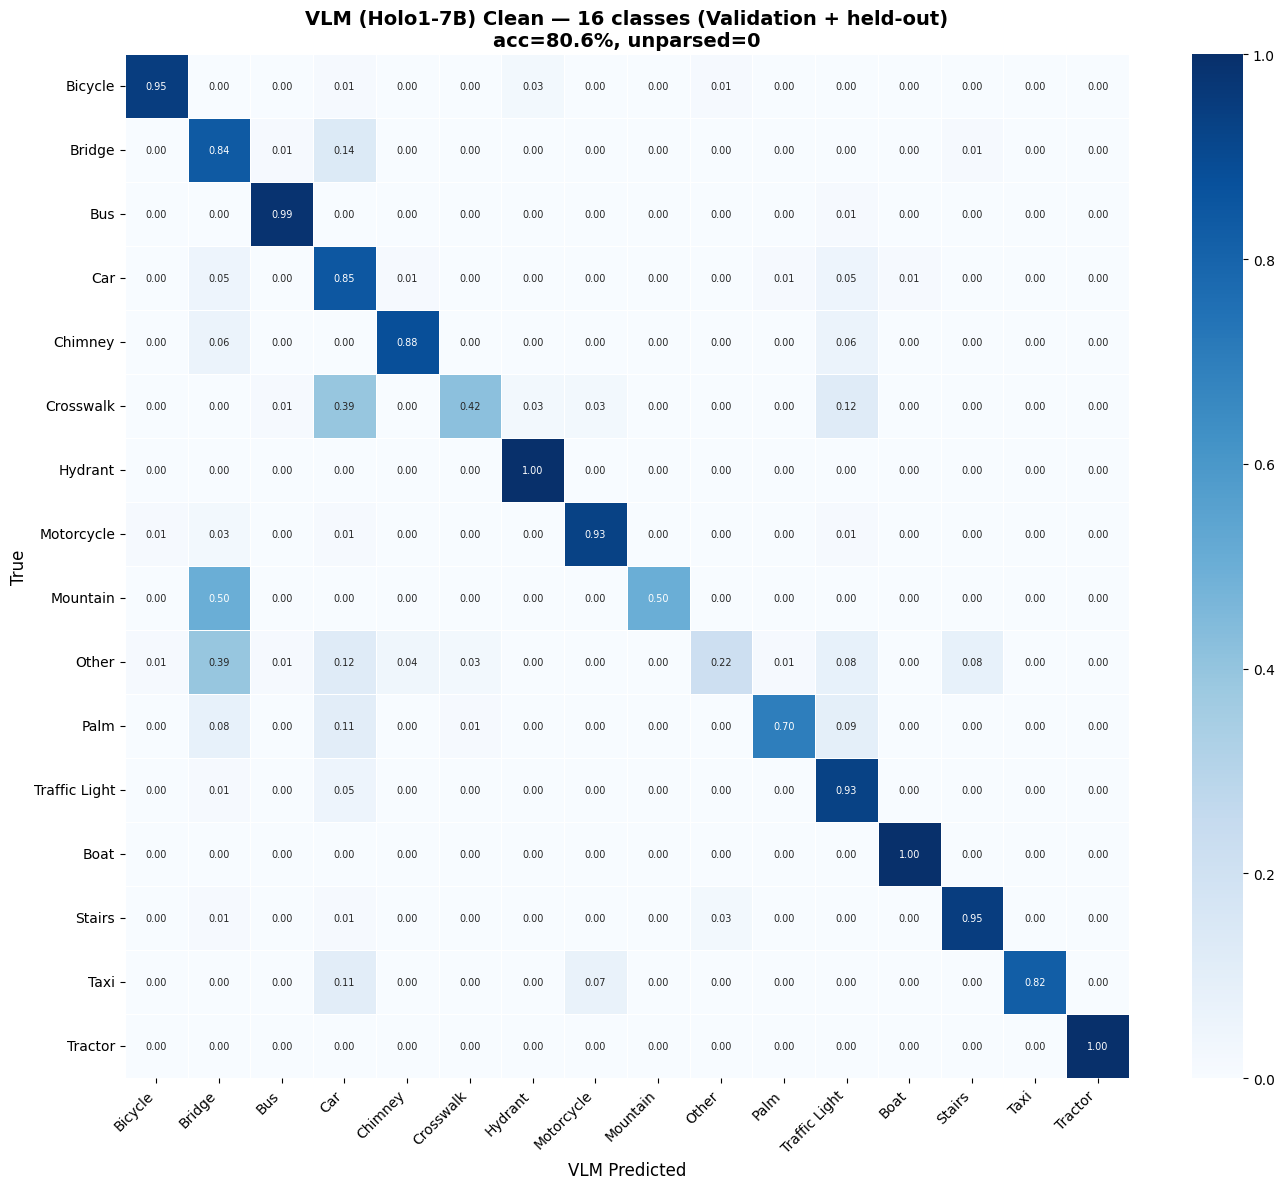

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# SANITY CHECK: VLM clean accuracy on all 16 classes
# Uses 16-class numeric prompt + first-match parsing
# Should reproduce previous results before proceeding
# ══════════════════════════════════════════════════════════════════════════════

ALL_16_CLASSES = [
    'Bicycle', 'Bridge', 'Bus', 'Car', 'Chimney', 'Crosswalk',
    'Hydrant', 'Motorcycle', 'Mountain', 'Other', 'Palm', 'Traffic Light',
    'Boat', 'Stairs', 'Taxi', 'Tractor'
]
N_16 = len(ALL_16_CLASSES)
CLASS16_TO_IDX = {cls: idx for idx, cls in enumerate(ALL_16_CLASSES)}

VLM_PROMPT_16 = (
    'Look at this image carefully and identify what object you see.\n\n'
    'Choose ONLY ONE number from the following list:\n\n'
    '0: Bicycle\n1: Bridge\n2: Bus\n3: Car\n4: Chimney\n'
    '5: Crosswalk\n6: Hydrant\n7: Motorcycle\n8: Mountain\n'
    '9: Other\n10: Palm\n11: Traffic Light\n'
    '12: Boat\n13: Stairs\n14: Taxi\n15: Tractor\n\n'
    'Answer with ONLY the number (0-15) of the class you see with the highest confidence.\n'
    'Do not include any explanation, just the number.\n\nAnswer: '
)

def parse_numeric_16(output_str):
    """Parse numeric VLM output (0-15). First-match + class name fallback."""
    numbers = re_mod.findall(r'\b(\d{1,2})\b', output_str.strip())
    if numbers:
        val = int(numbers[0])
        if 0 <= val <= 15:
            return val
    output_upper = output_str.upper()
    for cls_name, idx in CLASS16_TO_IDX.items():
        if cls_name.upper() in output_upper:
            return idx
    return -1

eval_classes = []
for cn in ALL_16_CLASSES:
    val_path = os.path.join(VAL_DIR, cn)
    if os.path.isdir(val_path):
        files = sorted([f for f in os.listdir(val_path)
                        if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))])
        if files:
            eval_classes.append({'class': cn, 'dir': val_path, 'source': 'Validation', 'files': files})
    if cn in ['Stairs', 'Taxi', 'Boat', 'Tractor']:
        train_path = os.path.join(TRAIN_DIR, cn)
        if os.path.isdir(train_path):
            files = sorted([f for f in os.listdir(train_path)
                            if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))])
            if files:
                eval_classes.append({'class': cn, 'dir': train_path, 'source': 'Training (held-out)', 'files': files})

print('SANITY CHECK: VLM clean accuracy (16-class numeric prompt)')
print(f'{"="*80}')

per_class_sanity = {}
vlm_cm_16 = np.zeros((N_16, N_16), dtype=int)  # 16x16 confusion matrix
vlm_cm_16_unparsed = 0

for entry in eval_classes:
    cn = entry['class']
    true_idx = CLASS16_TO_IDX[cn]
    class_correct = 0; class_total = 0

    for batch_start in range(0, len(entry['files']), VLM_BATCH):
        batch_fnames = entry['files'][batch_start:batch_start+VLM_BATCH]
        batch_pils = [resize_for_vlm(_original_open(os.path.join(entry['dir'], f)).convert('RGB'))
                      for f in batch_fnames]
        raw_outputs = vlm_batch_inference(batch_pils, VLM_PROMPT_16)
        for raw in raw_outputs:
            class_total += 1
            pred_idx = parse_numeric_16(raw)
            if pred_idx >= 0:
                vlm_cm_16[true_idx, pred_idx] += 1
                if pred_idx == true_idx:
                    class_correct += 1
            else:
                vlm_cm_16_unparsed += 1

    acc = class_correct / max(class_total, 1)
    per_class_sanity[cn] = {'correct': class_correct, 'total': class_total, 'source': entry['source']}
    print(f'  {cn:>14s} | {class_total:>4d} imgs | acc={acc:.0%} | {entry["source"]}')

total_c = sum(d['correct'] for d in per_class_sanity.values())
total_n = sum(d['total'] for d in per_class_sanity.values())
print(f'\nOverall: {total_c}/{total_n} ({total_c/total_n:.1%})')


# Plot 16-class VLM clean confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 12))
cm_norm = vlm_cm_16.astype(float) / np.maximum(vlm_cm_16.sum(axis=1, keepdims=True), 1)
vlm_16_acc = np.trace(vlm_cm_16) / max(vlm_cm_16.sum(), 1)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=ALL_16_CLASSES, yticklabels=ALL_16_CLASSES,
            vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_xlabel('VLM Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
ax.set_title(f'VLM (Holo1-7B) Clean — 16 classes (Validation + held-out)\n'
             f'acc={vlm_16_acc:.1%}, unparsed={vlm_cm_16_unparsed}',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, 'vlm_confusion_clean_16class.png'), bbox_inches='tight', dpi=300)
plt.show()

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# MAIN: VLM inference on ADVERSARIAL images (13 YOLO classes)
# ══════════════════════════════════════════════════════════════════════════════

NUMERIC16_TO_NAME = {i: cn for i, cn in enumerate(ALL_16_CLASSES)}

def numeric_pred_to_name(raw_output):
    """Parse numeric output, return predicted class name."""
    pred_idx = parse_numeric_16(raw_output)
    if pred_idx < 0:
        return 'UNPARSED'
    return NUMERIC16_TO_NAME[pred_idx]

VLM_RESULTS_CSV = os.path.join(SAVE_ROOT, 'vlm_results.csv')

existing_vlm_keys = set()
has_header = False
if os.path.exists(VLM_RESULTS_CSV):
    with open(VLM_RESULTS_CSV, 'r', newline='') as f:
        reader = csv.reader(f)
        first_row = next(reader, None)
        if first_row and first_row[0] == 'split':
            has_header = True
            for row in csv.DictReader(f, fieldnames=first_row):
                existing_vlm_keys.add((row['split'], row['class_name'], row['filename']))
    if existing_vlm_keys:
        print(f'Resuming: {len(existing_vlm_keys)} existing VLM results')

vlm_file = open(VLM_RESULTS_CSV, 'a', newline='')
vlm_writer = csv.writer(vlm_file)
if not has_header:
    vlm_writer.writerow(['split', 'class_name', 'filename', 'vlm_pred', 'vlm_correct',
                         'raw_output', 'adv_path'])

processed = 0; skipped = 0; unparsed = 0; correct = 0
t0 = time.time()

for split_name in ATTACK_SPLITS:
    print(f'\n{"="*80}')
    print(f'VLM adversarial: {split_name}')
    print(f'{"="*80}')

    for true_idx in range(N_CLASSES):
        class_name = CLASS_NAMES[true_idx]
        adv_class_dir = os.path.join(ADV_DIR, split_name, class_name)
        if not os.path.isdir(adv_class_dir): continue

        files = sorted([f for f in os.listdir(adv_class_dir) if f.lower().endswith('.png')])
        to_process = [f for f in files if (split_name, class_name, f) not in existing_vlm_keys]

        if not to_process:
            skipped += len(files)
            print(f'  {class_name:>14s} | {len(files):>4d} files | all skipped')
            continue

        class_processed = 0; class_correct = 0
        for batch_start in range(0, len(to_process), VLM_BATCH):
            batch_fnames = to_process[batch_start:batch_start+VLM_BATCH]
            batch_pils = [resize_for_vlm(_original_open(os.path.join(adv_class_dir, f)).convert('RGB'))
                          for f in batch_fnames]
            raw_outputs = vlm_batch_inference(batch_pils, VLM_PROMPT_16)

            for j, fname in enumerate(batch_fnames):
                pred_name = numeric_pred_to_name(raw_outputs[j])
                is_correct = int(pred_name == class_name)

                vlm_writer.writerow([
                    split_name, class_name, fname, pred_name,
                    is_correct, raw_outputs[j],
                    os.path.join(adv_class_dir, fname)
                ])
                processed += 1; class_processed += 1
                correct += is_correct; class_correct += is_correct
                if pred_name == 'UNPARSED': unparsed += 1

            vlm_file.flush()

        class_acc = class_correct / max(class_processed, 1)
        print(f'  {class_name:>14s} | {len(files):>4d} files | new={class_processed:>4d} | acc={class_acc:.0%}')

vlm_file.close()

print(f'\n{"="*80}')
print(f'Adversarial inference done in {time.time()-t0:.0f}s')
print(f'Processed: {processed}, Skipped: {skipped}, Unparsed: {unparsed}')
print(f'VLM accuracy on adv images: {correct}/{processed} ({correct/max(processed,1):.1%})')

Resuming: 11849 existing VLM results

VLM adversarial: Training
         Bicycle |  726 files | all skipped
          Bridge |  479 files | all skipped
             Bus | 1155 files | all skipped
             Car | 3504 files | all skipped
         Chimney |   39 files | all skipped
       Crosswalk | 1186 files | all skipped
         Hydrant |  898 files | all skipped
      Motorcycle |   27 files | all skipped
        Mountain |   11 files | all skipped
           Other | 1395 files | all skipped
            Palm |  858 files | all skipped
          Stairs |   75 files | all skipped
   Traffic Light |  737 files | all skipped

VLM adversarial: Validation
         Bicycle |   74 files | all skipped
          Bridge |   74 files | all skipped
             Bus |   74 files | all skipped
             Car |   74 files | all skipped
         Chimney |   17 files | all skipped
       Crosswalk |   74 files | all skipped
         Hydrant |   74 files | all skipped
      Motorcycle |   74 fil

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# MAIN: VLM inference on CLEAN images (13 YOLO classes)
# Same 16-class numeric prompt, same splits as adversarial
# ══════════════════════════════════════════════════════════════════════════════

VLM_CLEAN_CSV = os.path.join(SAVE_ROOT, 'vlm_clean_results.csv')

existing_clean_keys = set()
has_clean_header = False
if os.path.exists(VLM_CLEAN_CSV):
    with open(VLM_CLEAN_CSV, 'r', newline='') as f:
        reader = csv.reader(f)
        first_row = next(reader, None)
        if first_row and first_row[0] == 'split':
            has_clean_header = True
            for row in csv.DictReader(f, fieldnames=first_row):
                existing_clean_keys.add((row['split'], row['class_name'], row['filename']))
    if existing_clean_keys:
        print(f'Resuming clean: {len(existing_clean_keys)} existing results')

clean_file = open(VLM_CLEAN_CSV, 'a', newline='')
clean_writer = csv.writer(clean_file)
if not has_clean_header:
    clean_writer.writerow(['split', 'class_name', 'filename', 'vlm_pred', 'vlm_correct', 'raw_output'])

clean_processed = 0; clean_skipped = 0; clean_unparsed = 0; clean_correct = 0
t0 = time.time()

for split_name in ATTACK_SPLITS:
    split_dir = SPLIT_TO_DIR[split_name]
    print(f'\n{"="*80}')
    print(f'VLM clean: {split_name}')
    print(f'{"="*80}')

    for true_idx in range(N_CLASSES):
        class_name = CLASS_NAMES[true_idx]
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_dir): continue

        files = sorted([f for f in os.listdir(class_dir)
                        if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))])
        to_process = [f for f in files if (split_name, class_name, f) not in existing_clean_keys]

        if not to_process:
            clean_skipped += len(files)
            print(f'  {class_name:>14s} | {len(files):>4d} files | all skipped')
            continue

        class_proc = 0; class_corr = 0
        for batch_start in range(0, len(to_process), VLM_BATCH):
            batch_fnames = to_process[batch_start:batch_start+VLM_BATCH]
            batch_pils = [resize_for_vlm(_original_open(os.path.join(class_dir, f)).convert('RGB'))
                          for f in batch_fnames]
            raw_outputs = vlm_batch_inference(batch_pils, VLM_PROMPT_16)

            for j, fname in enumerate(batch_fnames):
                pred_name = numeric_pred_to_name(raw_outputs[j])
                is_correct = int(pred_name == class_name)

                clean_writer.writerow([
                    split_name, class_name, fname, pred_name,
                    is_correct, raw_outputs[j]
                ])
                clean_processed += 1; class_proc += 1
                clean_correct += is_correct; class_corr += is_correct
                if pred_name == 'UNPARSED': clean_unparsed += 1

            clean_file.flush()

        class_acc = class_corr / max(class_proc, 1)
        print(f'  {class_name:>14s} | {len(files):>4d} files | new={class_proc:>4d} | acc={class_acc:.0%}')

clean_file.close()

print(f'\n{"="*80}')
print(f'Clean inference done in {time.time()-t0:.0f}s')
print(f'Processed: {clean_processed}, Skipped: {clean_skipped}, Unparsed: {clean_unparsed}')
print(f'VLM accuracy on clean images: {clean_correct}/{clean_processed} ({clean_correct/max(clean_processed,1):.1%})')

Resuming clean: 11849 existing results

VLM clean: Training
         Bicycle |  726 files | all skipped
          Bridge |  479 files | all skipped
             Bus | 1155 files | all skipped
             Car | 3504 files | all skipped
         Chimney |   39 files | all skipped
       Crosswalk | 1186 files | all skipped
         Hydrant |  898 files | all skipped
      Motorcycle |   27 files | all skipped
        Mountain |   11 files | all skipped
           Other | 1395 files | all skipped
            Palm |  858 files | all skipped
          Stairs |   75 files | all skipped
   Traffic Light |  737 files | all skipped

VLM clean: Validation
         Bicycle |   74 files | all skipped
          Bridge |   74 files | all skipped
             Bus |   74 files | all skipped
             Car |   74 files | all skipped
         Chimney |   17 files | all skipped
       Crosswalk |   74 files | all skipped
         Hydrant |   74 files | all skipped
      Motorcycle |   74 files | all s

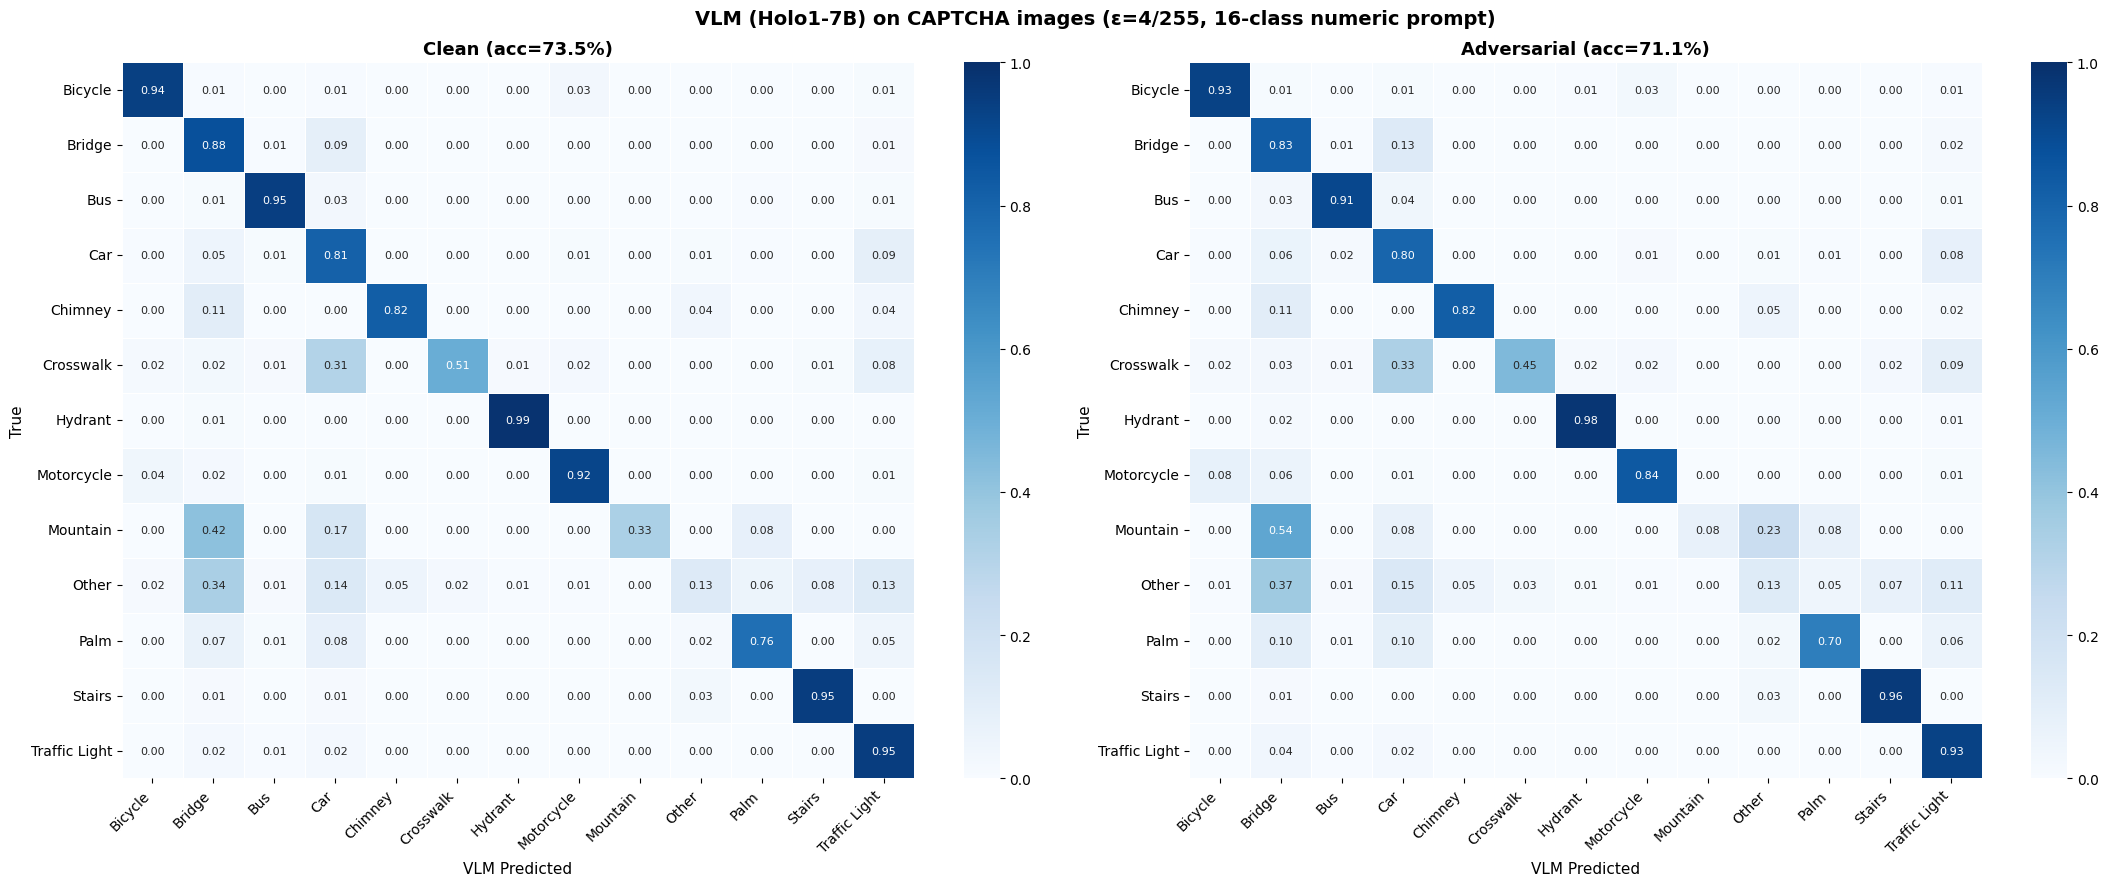


VLM accuracy: clean vs adversarial (13 YOLO classes)
Class             Clean acc    Adv acc     Drop
--------------------------------------------------
Bicycle                94%       93%    +0.7pp
Bridge                 88%       82%    +5.2pp
Bus                    94%       90%    +3.5pp
Car                    80%       78%    +1.3pp
Chimney                82%       82%    +0.0pp
Crosswalk              50%       45%    +5.3pp
Hydrant                99%       98%    +1.1pp
Motorcycle             91%       84%    +6.9pp
Mountain               31%        8%   +23.1pp
Other                  13%       12%    +0.5pp
Palm                   75%       70%    +5.4pp
Stairs                 95%       95%    +0.0pp
Traffic Light          94%       93%    +1.2pp
--------------------------------------------------
OVERALL              73.5%     71.1%    +2.4pp
MACRO AVG            75.8%     71.6%    +4.2pp

Clean: 11849 total, 0 unparsed, 112 predicted non-YOLO class
Adv:   11849 total, 0 unparse

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY: Clean vs Adversarial + confusion matrices
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns

# Load both CSVs
adv_rows = {}
with open(VLM_RESULTS_CSV, 'r', newline='') as f:
    for row in csv.DictReader(f):
        adv_rows[(row['split'], row['class_name'], row['filename'])] = row

clean_rows = {}
with open(VLM_CLEAN_CSV, 'r', newline='') as f:
    for row in csv.DictReader(f):
        clean_rows[(row['split'], row['class_name'], row['filename'])] = row

# Build confusion matrices (13x13 for YOLO classes)
adv_cm = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
clean_cm = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
adv_unparsed = 0; clean_unparsed_count = 0
adv_non_yolo = 0; clean_non_yolo = 0

for row in adv_rows.values():
    ti = NAME_TO_IDX[row['class_name']]
    pn = row['vlm_pred']
    if pn == 'UNPARSED':
        adv_unparsed += 1; continue
    if pn not in NAME_TO_IDX:
        adv_non_yolo += 1; continue
    adv_cm[ti, NAME_TO_IDX[pn]] += 1

for row in clean_rows.values():
    ti = NAME_TO_IDX[row['class_name']]
    pn = row['vlm_pred']
    if pn == 'UNPARSED':
        clean_unparsed_count += 1; continue
    if pn not in NAME_TO_IDX:
        clean_non_yolo += 1; continue
    clean_cm[ti, NAME_TO_IDX[pn]] += 1

n_clean_total = len(clean_rows)
n_adv_total = len(adv_rows)
vlm_clean_correct = sum(1 for r in clean_rows.values() if int(r['vlm_correct']) == 1)
vlm_adv_correct = sum(1 for r in adv_rows.values() if int(r['vlm_correct']) == 1)
vlm_clean_acc = vlm_clean_correct / max(n_clean_total, 1)
vlm_adv_acc = vlm_adv_correct / max(n_adv_total, 1)

# Confusion matrix plot
class_labels = [CLASS_NAMES[i] for i in range(N_CLASSES)]
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, cm, title in [(axes[0], clean_cm, f'Clean (acc={vlm_clean_acc:.1%})'),
                       (axes[1], adv_cm, f'Adversarial (acc={vlm_adv_acc:.1%})')]:
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_xlabel('VLM Predicted', fontsize=11); ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('VLM (Holo1-7B) on CAPTCHA images (\u03b5=4/255, 16-class numeric prompt)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, 'vlm_confusion_clean_vs_adv.png'), bbox_inches='tight', dpi=300)
plt.show()

# Per-class table (13 YOLO classes — adversarial pipeline)
print(f'\n{"="*70}')
print(f'VLM accuracy: clean vs adversarial (13 YOLO classes)')
print(f'{"="*70}')
print(f'{"Class":<16s} {"Clean acc":>10s} {"Adv acc":>10s} {"Drop":>8s}')
print(f'{"-"*50}')
clean_per_class_accs = []
adv_per_class_accs = []
for i in range(N_CLASSES):
    cn = CLASS_NAMES[i]
    c_total = sum(1 for r in clean_rows.values() if r['class_name'] == cn)
    c_correct = sum(1 for r in clean_rows.values() if r['class_name'] == cn and int(r['vlm_correct']) == 1)
    a_total = sum(1 for r in adv_rows.values() if r['class_name'] == cn)
    a_correct = sum(1 for r in adv_rows.values() if r['class_name'] == cn and int(r['vlm_correct']) == 1)
    c_acc = c_correct / max(c_total, 1)
    a_acc = a_correct / max(a_total, 1)
    if c_total > 0: clean_per_class_accs.append(c_acc)
    if a_total > 0: adv_per_class_accs.append(a_acc)
    print(f'{cn:<16s} {c_acc:>9.0%} {a_acc:>9.0%} {(c_acc - a_acc)*100:>+7.1f}pp')

clean_macro = np.mean(clean_per_class_accs)
adv_macro = np.mean(adv_per_class_accs)

print(f'{"-"*50}')
print(f'{"OVERALL":<16s} {vlm_clean_acc:>9.1%} {vlm_adv_acc:>9.1%} {(vlm_clean_acc - vlm_adv_acc)*100:>+7.1f}pp')
print(f'{"MACRO AVG":<16s} {clean_macro:>9.1%} {adv_macro:>9.1%} {(clean_macro - adv_macro)*100:>+7.1f}pp')
print(f'\nClean: {n_clean_total} total, {clean_unparsed_count} unparsed, {clean_non_yolo} predicted non-YOLO class')
print(f'Adv:   {n_adv_total} total, {adv_unparsed} unparsed, {adv_non_yolo} predicted non-YOLO class')

# ── VLM accuracy on all 16 classes (clean, from sanity check data) ────────────
print(f'\n\n{"="*70}')
print(f'VLM clean accuracy: all 16 classes (Validation + held-out)')
print(f'{"="*70}')
print(f'{"Class":<16s} {"N":>5s} {"Correct":>8s} {"Acc":>7s} {"Source":<25s}')
print(f'{"-"*65}')
vlm_16_per_class_accs = []
for cn in ALL_16_CLASSES:
    d = per_class_sanity.get(cn)
    if d is None or d['total'] == 0:
        print(f'{cn:<16s} {"0":>5s} {"0":>8s} {"N/A":>7s}')
        continue
    acc = d['correct'] / d['total']
    vlm_16_per_class_accs.append(acc)
    print(f'{cn:<16s} {d["total"]:>5d} {d["correct"]:>8d} {acc:>6.0%} {d["source"]:<25s}')

vlm_16_total = sum(d['total'] for d in per_class_sanity.values())
vlm_16_correct = sum(d['correct'] for d in per_class_sanity.values())
vlm_16_overall = vlm_16_correct / max(vlm_16_total, 1)
vlm_16_macro = np.mean(vlm_16_per_class_accs)
print(f'{"-"*65}')
print(f'Overall accuracy:  {vlm_16_overall:.1%} ({vlm_16_correct}/{vlm_16_total})')
print(f'Macro accuracy:    {vlm_16_macro:.1%} (avg of {len(vlm_16_per_class_accs)} classes)')

# Save
np.save(os.path.join(SAVE_ROOT, 'vlm_confusion_adv.npy'), adv_cm)
np.save(os.path.join(SAVE_ROOT, 'vlm_confusion_clean.npy'), clean_cm)
print(f'\n\u2713 Step 2 v3 complete.')

## Sanity check: YOLO clean accuracy on all 16 classes

The cell below is **not part of the main Step 2 pipeline** — it evaluates the YOLO classification model on clean images for reference. This provides the YOLO baseline confusion matrices (Training + Validation) that appear in the paper. Stairs/Taxi/Boat/Tractor training samples are treated as held-out validation. YOLO was not trained on Taxi/Boat/Tractor so those will show 0%.

Evaluating YOLO on all 16 classes...
YOLO evaluation done.

YOLO — 16 classes (Validation + held-out)
Class                N    Prec     Rec      F1  Note                
------------------------------------------------------------------------
Bicycle             74   79.5%   89.2%   84.1%                      
Bridge              74   82.7%   83.8%   83.2%                      
Bus                 74   83.7%   97.3%   90.0%                      
Car                 74   41.5%   75.7%   53.6%                      
Chimney             17   85.7%   70.6%   77.4%                      
Crosswalk           74   84.6%   89.2%   86.8%                      
Hydrant             74   96.1%  100.0%   98.0%                      
Motorcycle          74   87.9%   68.9%   77.3%                      
Mountain             2    0.0%    0.0%    0.0%                      
Other               74   44.4%   64.9%   52.7%                      
Palm                74   95.1%   78.4%   85.9%                    

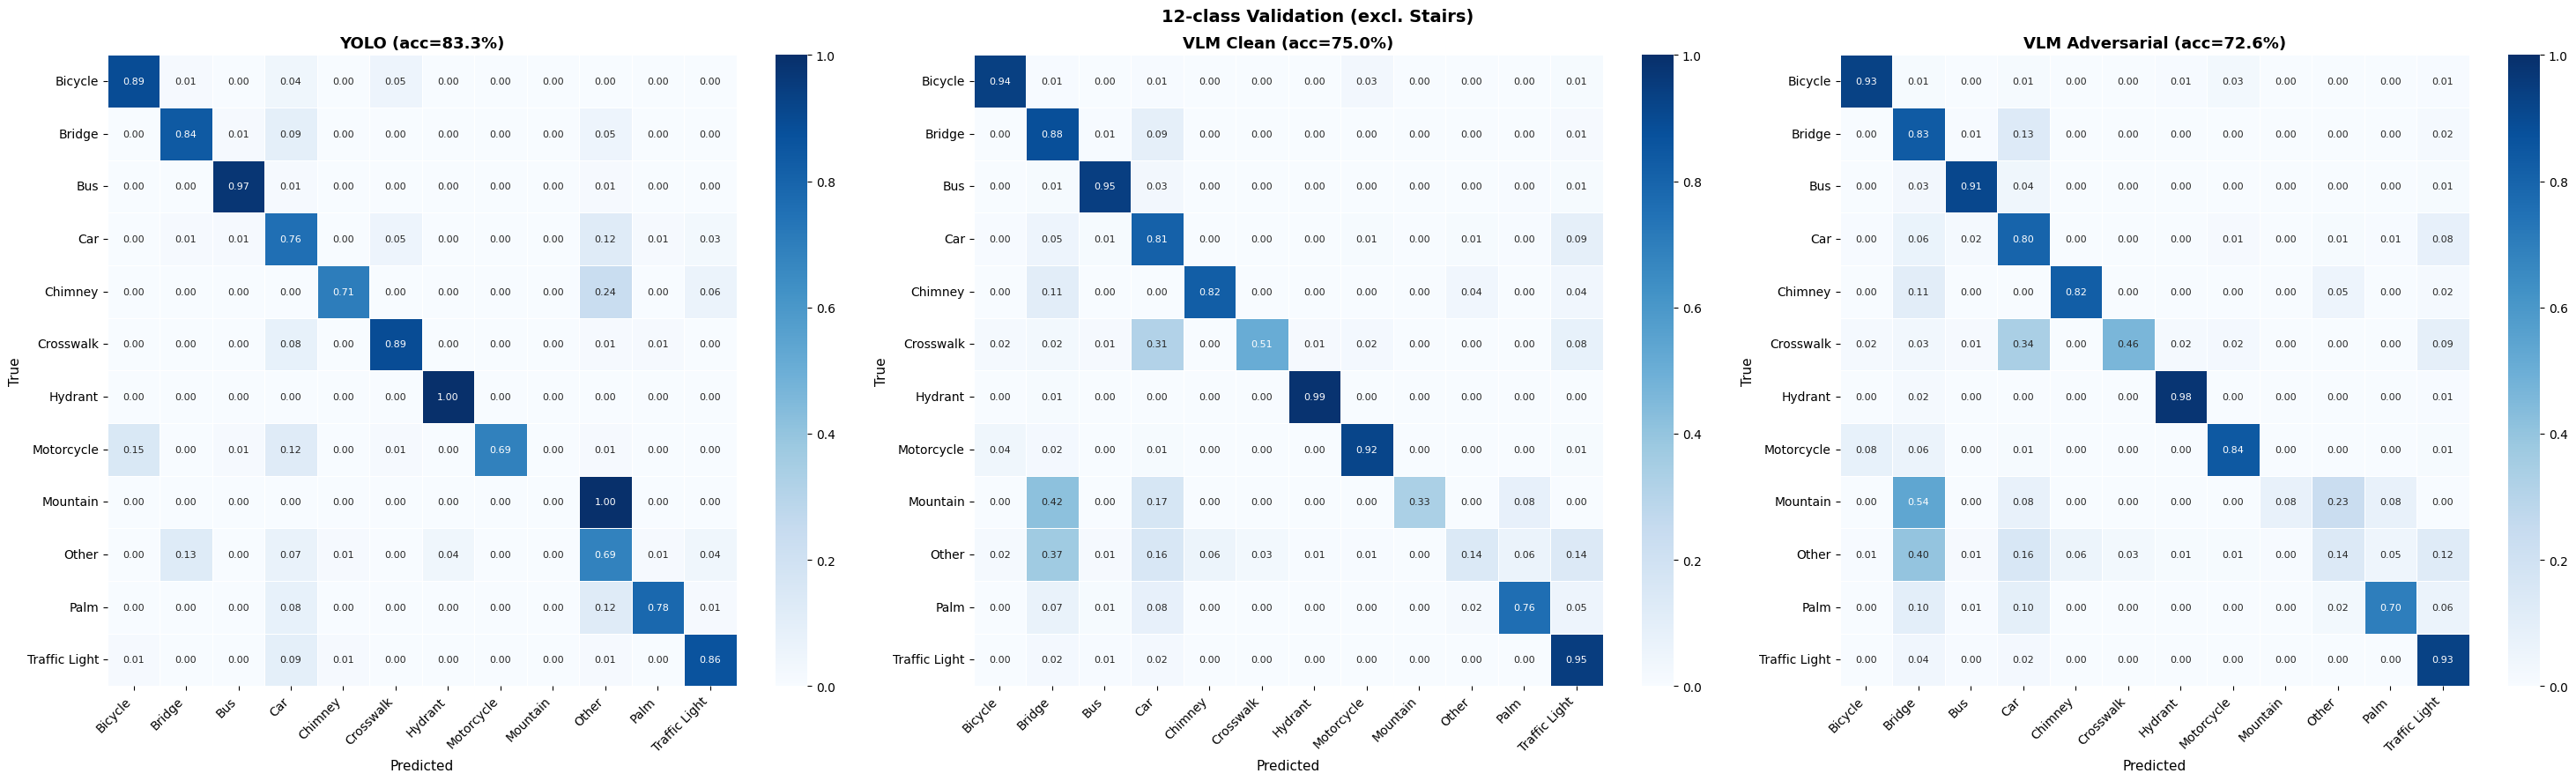

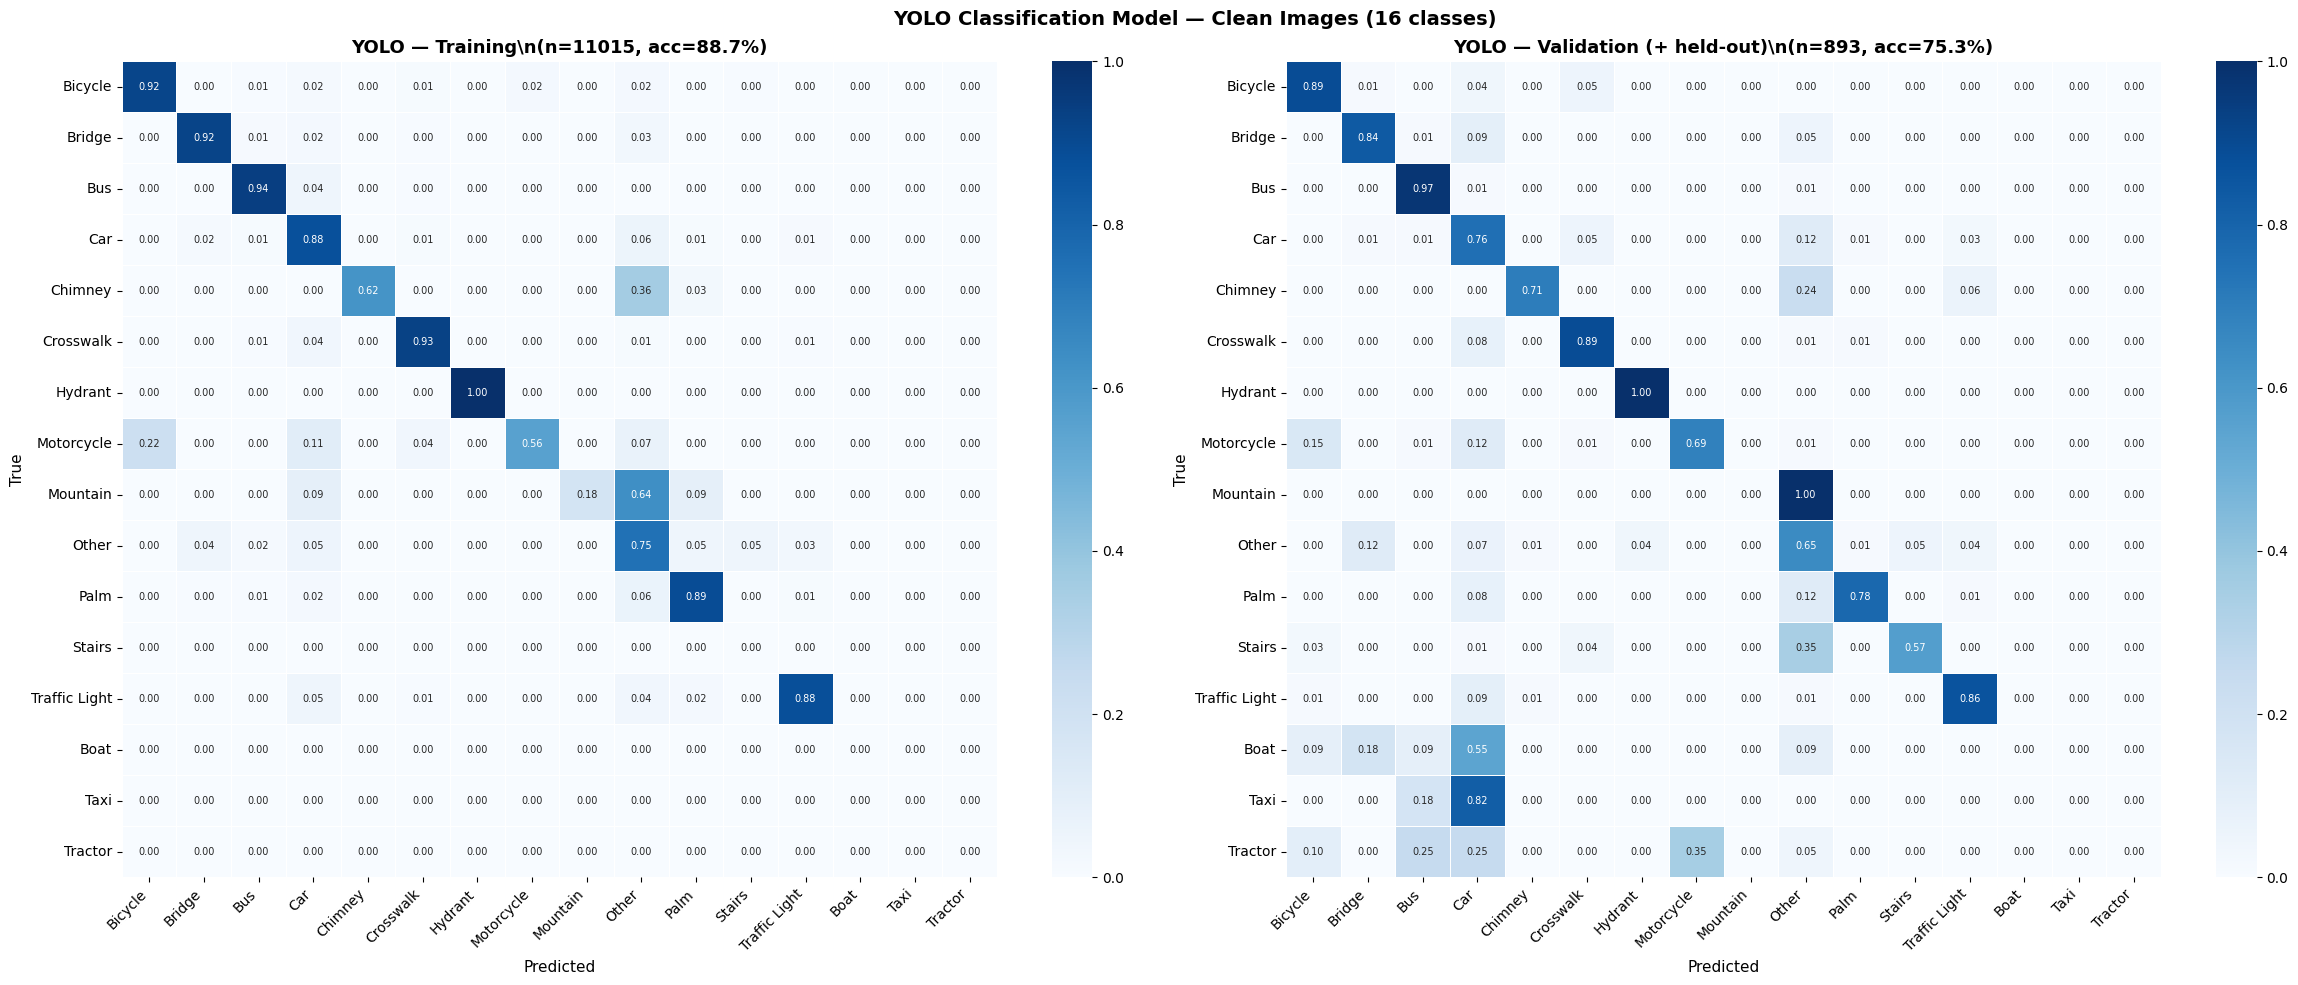


YOLO — 12 classes (Training only, excl. Stairs)
Class                N    Prec     Rec      F1
--------------------------------------------------
Bicycle            723   96.8%   92.3%   94.5%
Bridge             479   77.7%   92.3%   84.4%
Bus               1155   92.4%   94.3%   93.3%
Car               3501   92.4%   87.7%   90.0%
Chimney             39   75.0%   61.5%   67.6%
Crosswalk         1186   94.9%   93.1%   94.0%
Hydrant            897   99.6%   99.9%   99.7%
Motorcycle          27   37.5%   55.6%   44.8%
Mountain            11   66.7%   18.2%   28.6%
Other             1331   74.7%   78.4%   76.5%
Palm               858   86.2%   89.3%   87.7%
Traffic Light      737   85.3%   88.2%   86.7%
--------------------------------------------------
Overall acc      10944           89.3%
Macro avg                81.6%   79.2%   79.0%

VLM — 12 classes (Training only, clean)
Class                N    Prec     Rec      F1
--------------------------------------------------
Bicycle      

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Comprehensive per-class metrics: Precision, Recall, F1
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns

# ── YOLO evaluation (16-class, Training + Validation) ─────────────────────────
from ultralytics import YOLO
yolo_eval = YOLO(MODEL_DST)
yolo_model = yolo_eval.model.to(device).eval()
IMG_SIZE = 128
preprocess = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

def yolo_forward_probs(x):
    out = yolo_model(x.to(device))
    return out[0] if isinstance(out, tuple) else out

ALL_16_LABELS = [
    'Bicycle', 'Bridge', 'Bus', 'Car', 'Chimney', 'Crosswalk',
    'Hydrant', 'Motorcycle', 'Mountain', 'Other', 'Palm', 'Stairs', 'Traffic Light',
    'Boat', 'Taxi', 'Tractor'
]
N_16 = len(ALL_16_LABELS)
LABEL16_TO_IDX = {cn: i for i, cn in enumerate(ALL_16_LABELS)}

held_out_classes = {'Stairs', 'Taxi', 'Boat', 'Tractor'}

yolo_eval_sets = []
for split_name in ['Training', 'Validation']:
    split_dir = SPLIT_TO_DIR[split_name]
    for cn in ALL_16_LABELS:
        class_dir = os.path.join(split_dir, cn)
        if not os.path.isdir(class_dir): continue
        files = sorted([f for f in os.listdir(class_dir)
                        if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))])
        if files:
            yolo_eval_sets.append({'class': cn, 'dir': class_dir, 'split': split_name, 'files': files})

yolo_cm_train = np.zeros((N_16, N_16), dtype=int)
yolo_cm_val = np.zeros((N_16, N_16), dtype=int)

print('Evaluating YOLO on all 16 classes...')
for entry in yolo_eval_sets:
    cn = entry['class']
    true_16_idx = LABEL16_TO_IDX[cn]
    for fname in entry['files']:
        img = preprocess(_original_open(os.path.join(entry['dir'], fname)).convert('RGB'))
        with torch.no_grad():
            probs = yolo_forward_probs(img.unsqueeze(0)).cpu().squeeze()
        yolo_pred_name = CLASS_NAMES[probs.argmax().item()]
        pred_16_idx = LABEL16_TO_IDX[yolo_pred_name]
        if entry['split'] == 'Validation' or cn in held_out_classes:
            yolo_cm_val[true_16_idx, pred_16_idx] += 1
        else:
            yolo_cm_train[true_16_idx, pred_16_idx] += 1

del yolo_eval, yolo_model; torch.cuda.empty_cache()
print('YOLO evaluation done.')

# ── Helper functions ──────────────────────────────────────────────────────────
def compute_prf(cm, class_names):
    metrics = {}
    for i, cn in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        total = cm[i, :].sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        metrics[cn] = {'prec': prec, 'rec': rec, 'f1': f1, 'tp': int(tp), 'total': int(total)}
    return metrics

def print_prf_table(title, cm, class_names, notes=None):
    metrics = compute_prf(cm, class_names)
    print(f'\n{"="*75}')
    print(f'{title}')
    print(f'{"="*75}')
    print(f'{"Class":<16s} {"N":>5s} {"Prec":>7s} {"Rec":>7s} {"F1":>7s}', end='')
    if notes: print(f'  {"Note":<20s}', end='')
    print()
    print(f'{"-"*50}', end='')
    if notes: print(f'{"-"*22}', end='')
    print()
    precs, recs, f1s = [], [], []
    for cn in class_names:
        m = metrics[cn]
        note = notes.get(cn, '') if notes else ''
        print(f'{cn:<16s} {m["total"]:>5d} {m["prec"]*100:>6.1f}% {m["rec"]*100:>6.1f}% {m["f1"]*100:>6.1f}%', end='')
        if notes: print(f'  {note:<20s}', end='')
        print()
        if m['total'] > 0:
            precs.append(m['prec']); recs.append(m['rec']); f1s.append(m['f1'])
    total_samples = cm.sum()
    overall_acc = np.trace(cm) / max(total_samples, 1)
    macro_prec = np.mean(precs); macro_rec = np.mean(recs); macro_f1 = np.mean(f1s)
    print(f'{"-"*50}')
    print(f'{"Overall acc":<16s} {int(total_samples):>5d} {"":<7s} {overall_acc*100:>6.1f}%')
    print(f'{"Macro avg":<16s} {"":>5s} {macro_prec*100:>6.1f}% {macro_rec*100:>6.1f}% {macro_f1*100:>6.1f}%')
    return metrics

# ── 16-class: YOLO vs VLM (Validation + held-out) ────────────────────────────
yolo_16_notes = {cn: '(unsupported)' for cn in ['Taxi', 'Boat', 'Tractor']}
yolo_16_notes['Stairs'] = '(held-out)'
print_prf_table('YOLO \u2014 16 classes (Validation + held-out)', yolo_cm_val, ALL_16_LABELS, yolo_16_notes)

vlm_16_notes = {cn: '(held-out)' for cn in ['Stairs', 'Taxi', 'Boat', 'Tractor']}
print_prf_table('VLM \u2014 16 classes (Validation + held-out, clean images)', vlm_cm_16, ALL_16_CLASSES, vlm_16_notes)

# ── 12-class: Validation only, excluding Stairs ──────────────────────────────
VAL_12_CLASSES = [cn for cn in [CLASS_NAMES[i] for i in range(N_CLASSES)] if cn != 'Stairs']
VAL_12_IDXS = [NAME_TO_IDX[cn] for cn in VAL_12_CLASSES]

clean_cm_12 = clean_cm[np.ix_(VAL_12_IDXS, VAL_12_IDXS)]
adv_cm_12 = adv_cm[np.ix_(VAL_12_IDXS, VAL_12_IDXS)]

yolo_12_16idxs = [LABEL16_TO_IDX[cn] for cn in VAL_12_CLASSES]
yolo_cm_12 = yolo_cm_val[np.ix_(yolo_12_16idxs, yolo_12_16idxs)]

print_prf_table('YOLO \u2014 12 classes (Validation only, excl. Stairs)', yolo_cm_12, VAL_12_CLASSES)
print_prf_table('VLM \u2014 12 classes (Validation only, clean)', clean_cm_12, VAL_12_CLASSES)
print_prf_table('VLM \u2014 12 classes (Validation only, adversarial)', adv_cm_12, VAL_12_CLASSES)

# Plot 12-class confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(30, 9))
for ax, cm, title in [(axes[0], yolo_cm_12, 'YOLO'),
                       (axes[1], clean_cm_12, 'VLM Clean'),
                       (axes[2], adv_cm_12, 'VLM Adversarial')]:
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    acc = np.trace(cm) / max(cm.sum(), 1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=VAL_12_CLASSES, yticklabels=VAL_12_CLASSES,
                vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('True', fontsize=11)
    ax.set_title(f'{title} (acc={acc:.1%})', fontsize=13, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.suptitle('12-class Validation (excl. Stairs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, 'confusion_12class_val.png'), bbox_inches='tight', dpi=300)
plt.show()

# Plot 16-class YOLO confusion matrices (Training + Validation)
fig, axes = plt.subplots(1, 2, figsize=(24, 10))
for ax, cm, title in [(axes[0], yolo_cm_train, 'YOLO \u2014 Training'),
                       (axes[1], yolo_cm_val, 'YOLO \u2014 Validation (+ held-out)')]:
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    total = cm.sum(); acc = np.trace(cm) / max(total, 1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=ALL_16_LABELS, yticklabels=ALL_16_LABELS,
                vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 7})
    ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('True', fontsize=11)
    ax.set_title(f'{title}\\n(n={total}, acc={acc:.1%})', fontsize=13, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right'); plt.setp(ax.get_yticklabels(), rotation=0)
plt.suptitle('YOLO Classification Model \u2014 Clean Images (16 classes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, 'yolo_confusion_clean_16class.png'), bbox_inches='tight', dpi=300)
plt.show()

# ── Training-only: 12 classes (excl. Stairs) ─────────────────────────────────
TRAIN_12_CLASSES = [cn for cn in [CLASS_NAMES[i] for i in range(N_CLASSES)] if cn != 'Stairs']
TRAIN_12_IDXS = [NAME_TO_IDX[cn] for cn in TRAIN_12_CLASSES]

vlm_cm_train_clean = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
vlm_cm_train_adv = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for row in clean_rows.values():
    if row['split'] != 'Training': continue
    cn = row['class_name']
    if cn not in NAME_TO_IDX: continue
    pn = row['vlm_pred']
    if pn in NAME_TO_IDX:
        vlm_cm_train_clean[NAME_TO_IDX[cn], NAME_TO_IDX[pn]] += 1
for row in adv_rows.values():
    if row['split'] != 'Training': continue
    cn = row['class_name']
    if cn not in NAME_TO_IDX: continue
    pn = row['vlm_pred']
    if pn in NAME_TO_IDX:
        vlm_cm_train_adv[NAME_TO_IDX[cn], NAME_TO_IDX[pn]] += 1

vlm_train_clean_12 = vlm_cm_train_clean[np.ix_(TRAIN_12_IDXS, TRAIN_12_IDXS)]
vlm_train_adv_12 = vlm_cm_train_adv[np.ix_(TRAIN_12_IDXS, TRAIN_12_IDXS)]
yolo_train_12_16idxs = [LABEL16_TO_IDX[cn] for cn in TRAIN_12_CLASSES]
yolo_train_12 = yolo_cm_train[np.ix_(yolo_train_12_16idxs, yolo_train_12_16idxs)]

print_prf_table('YOLO \u2014 12 classes (Training only, excl. Stairs)', yolo_train_12, TRAIN_12_CLASSES)
print_prf_table('VLM \u2014 12 classes (Training only, clean)', vlm_train_clean_12, TRAIN_12_CLASSES)
print_prf_table('VLM \u2014 12 classes (Training only, adversarial)', vlm_train_adv_12, TRAIN_12_CLASSES)

# ── YOLO vs VLM (Prec/Rec/F1) ──────────────────────────
print(f'\\n\\n{"="*90}')
print(f'Paper table: YOLO vs VLM per-class (16 classes, Validation + held-out)')
print(f'{"="*90}')
print(f'{"Class":<16s} | {"YOLO Prec":>10s} {"Rec":>7s} {"F1":>7s} | {"VLM Prec":>10s} {"Rec":>7s} {"F1":>7s}')
print(f'{"-"*75}')
yolo_m = compute_prf(yolo_cm_val, ALL_16_LABELS)
vlm_m = compute_prf(vlm_cm_16, ALL_16_CLASSES)
y_precs, y_recs, y_f1s = [], [], []
v_precs, v_recs, v_f1s = [], [], []
for cn in ALL_16_CLASSES:
    ym = yolo_m.get(cn, {'prec':0,'rec':0,'f1':0,'total':0})
    vm = vlm_m.get(cn, {'prec':0,'rec':0,'f1':0,'total':0})
    marker = '\u2020' if cn in ['Boat', 'Taxi', 'Tractor'] else ''
    print(f'{cn+marker:<16s} | {ym["prec"]*100:>9.1f}% {ym["rec"]*100:>6.1f}% {ym["f1"]*100:>6.1f}% | {vm["prec"]*100:>9.1f}% {vm["rec"]*100:>6.1f}% {vm["f1"]*100:>6.1f}%')
    if ym['total'] > 0: y_precs.append(ym['prec']); y_recs.append(ym['rec']); y_f1s.append(ym['f1'])
    if vm['total'] > 0: v_precs.append(vm['prec']); v_recs.append(vm['rec']); v_f1s.append(vm['f1'])
print(f'{"-"*75}')
print(f'{"Macro avg":<16s} | {np.mean(y_precs)*100:>9.1f}% {np.mean(y_recs)*100:>6.1f}% {np.mean(y_f1s)*100:>6.1f}% | {np.mean(v_precs)*100:>9.1f}% {np.mean(v_recs)*100:>6.1f}% {np.mean(v_f1s)*100:>6.1f}%')
print(f'\\n\u2020 = Unsupported by YOLO classification model')

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# VLM split-level summary: Validation vs Training
# No inference needed — just reads the saved predictions
# ══════════════════════════════════════════════════════════════════════════════

# Load CSVs if not already loaded
if 'adv_rows' not in dir():
    adv_rows = {}
    with open(VLM_RESULTS_CSV, 'r', newline='') as f:
        for row in csv.DictReader(f):
            adv_rows[(row['split'], row['class_name'], row['filename'])] = row
    clean_rows = {}
    with open(VLM_CLEAN_CSV, 'r', newline='') as f:
        for row in csv.DictReader(f):
            clean_rows[(row['split'], row['class_name'], row['filename'])] = row

def split_summary(split_name, rows_clean, rows_adv, class_list, title):
    """Print per-class clean vs adv accuracy for a given split."""
    print(f'\n{"="*70}')
    print(f'{title}')
    print(f'{"="*70}')
    print(f'{"Class":<16s} {"N cln":>6s} {"Cln acc":>8s} {"N adv":>6s} {"Adv acc":>8s} {"Drop":>8s}')
    print(f'{"-"*55}')

    per_class_clean = []; per_class_adv = []
    total_c = 0; total_a = 0; correct_c = 0; correct_a = 0

    for cn in class_list:
        c_rows = [(k, r) for k, r in rows_clean.items() if r['split'] == split_name and r['class_name'] == cn]
        a_rows = [(k, r) for k, r in rows_adv.items() if r['split'] == split_name and r['class_name'] == cn]
        c_total = len(c_rows)
        a_total = len(a_rows)
        c_correct = sum(1 for _, r in c_rows if int(r['vlm_correct']) == 1)
        a_correct = sum(1 for _, r in a_rows if int(r['vlm_correct']) == 1)
        c_acc = c_correct / max(c_total, 1)
        a_acc = a_correct / max(a_total, 1)

        if c_total > 0: per_class_clean.append(c_acc)
        if a_total > 0: per_class_adv.append(a_acc)
        total_c += c_total; total_a += a_total
        correct_c += c_correct; correct_a += a_correct

        if c_total > 0 or a_total > 0:
            print(f'{cn:<16s} {c_total:>6d} {c_acc:>7.0%} {a_total:>6d} {a_acc:>7.0%} {(c_acc-a_acc)*100:>+7.1f}pp')

    overall_c = correct_c / max(total_c, 1)
    overall_a = correct_a / max(total_a, 1)
    macro_c = np.mean(per_class_clean) if per_class_clean else 0
    macro_a = np.mean(per_class_adv) if per_class_adv else 0
    print(f'{"-"*55}')
    print(f'{"OVERALL":<16s} {total_c:>6d} {overall_c:>7.1%} {total_a:>6d} {overall_a:>7.1%} {(overall_c-overall_a)*100:>+7.1f}pp')
    print(f'{"MACRO AVG":<16s} {"":>6s} {macro_c:>7.1%} {"":>6s} {macro_a:>7.1%} {(macro_c-macro_a)*100:>+7.1f}pp')
    return {'overall_clean': overall_c, 'overall_adv': overall_a,
            'macro_clean': macro_c, 'macro_adv': macro_a,
            'n_clean': total_c, 'n_adv': total_a}

YOLO_13 = [CLASS_NAMES[i] for i in range(N_CLASSES)]

# Validation only (759 samples per condition)
val_stats = split_summary('Validation', clean_rows, adv_rows, YOLO_13,
    'VLM — Validation only (13 YOLO classes, clean vs adversarial)')

# Training only (11090 samples per condition)
train_stats = split_summary('Training', clean_rows, adv_rows, YOLO_13,
    'VLM — Training only (13 YOLO classes, clean vs adversarial)')

# Quick comparison
print(f'\n\n{"="*70}')
print(f'Summary: VLM accuracy by split')
print(f'{"="*70}')
print(f'{"Split":<12s} {"N":>6s} | {"Clean":>8s} {"Adv":>8s} {"Drop":>8s} | {"Macro cln":>10s} {"Macro adv":>10s}')
print(f'{"-"*70}')
print(f'{"Validation":<12s} {val_stats["n_clean"]:>6d} | {val_stats["overall_clean"]:>7.1%} {val_stats["overall_adv"]:>7.1%} {(val_stats["overall_clean"]-val_stats["overall_adv"])*100:>+7.1f}pp | {val_stats["macro_clean"]:>9.1%} {val_stats["macro_adv"]:>9.1%}')
print(f'{"Training":<12s} {train_stats["n_clean"]:>6d} | {train_stats["overall_clean"]:>7.1%} {train_stats["overall_adv"]:>7.1%} {(train_stats["overall_clean"]-train_stats["overall_adv"])*100:>+7.1f}pp | {train_stats["macro_clean"]:>9.1%} {train_stats["macro_adv"]:>9.1%}')

both_c = (val_stats["n_clean"] * val_stats["overall_clean"] + train_stats["n_clean"] * train_stats["overall_clean"]) / (val_stats["n_clean"] + train_stats["n_clean"])
both_a = (val_stats["n_adv"] * val_stats["overall_adv"] + train_stats["n_adv"] * train_stats["overall_adv"]) / (val_stats["n_adv"] + train_stats["n_adv"])
print(f'{"Both":<12s} {val_stats["n_clean"]+train_stats["n_clean"]:>6d} | {both_c:>7.1%} {both_a:>7.1%} {(both_c-both_a)*100:>+7.1f}pp |')


VLM — Validation only (13 YOLO classes, clean vs adversarial)
Class             N cln  Cln acc  N adv  Adv acc     Drop
-------------------------------------------------------
Bicycle              74     95%     74     92%    +2.7pp
Bridge               74     85%     74     81%    +4.1pp
Bus                  74     99%     74     93%    +5.4pp
Car                  74     85%     74     74%   +10.8pp
Chimney              17     88%     17     88%    +0.0pp
Crosswalk            74     43%     74     42%    +1.4pp
Hydrant              74    100%     74     99%    +1.4pp
Motorcycle           74     93%     74     89%    +4.1pp
Mountain              2     50%      2     50%    +0.0pp
Other                74     22%     74     15%    +6.8pp
Palm                 74     70%     74     66%    +4.1pp
Traffic Light        74     93%     74     96%    -2.7pp
-------------------------------------------------------
OVERALL             759   78.7%    759   75.0%    +3.7pp
MACRO AVG                 